# 03 - Illinois Enrollment Trends
We want to look at correlation between where the students are coming from (city or what school within IL) with their enrollment trends (e.g. what courses they enroll in).

**Scope:** city level within IL

**Unit of analysis:** one row = one enrollment (one `students` record).

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.mongo_connect import get_db
from src.location import add_location_columns

db = get_db()
print(db.name)

nexus


## 1. Build `df_enrollment`
### 1.1 Load students + flatten location
Window = full academic years starting from AY 2021-22 (`term >= 120227`), so the start lines up with a term boundary. Same address logic as notebook 02 (shared via `src/location.py`).

In [2]:
START_TERM = 120227  # AY 2021-22

df_raw = pd.DataFrame(list(db.students.find({
    "term": {"$gte": START_TERM}
})))
df_raw = add_location_columns(df_raw)
print(df_raw.shape)

# columns we care about for df_enrollment (skip any that don't exist)
PREVIEW_COLS = [c for c in ["_id", "term", "course", "enrollDate", "startDate", "status", "isAdult",
                            "city", "state", "zip", "country"] if c in df_raw.columns]
df_raw[PREVIEW_COLS].head()

(10184, 60)


,_id,term,course,enrollDate,startDate,status,isAdult,city,state,zip,country
0,6126414509152102b965f7a9,120227,286,2021-08-24 20:07:52,2021-08-24 05:00:00.000,Completed,False,Naperville,IL,60564-8907,United States
1,6126414609152102b965f7ab,120227,220,2021-08-24 22:01:21,2021-09-07 05:00:00.000,Completed,True,Champaign,IL,61821-7030,United States
2,6126414609152102b965f7ad,120227,241,2021-08-24 22:17:01,2021-09-22 13:10:23.615,Withdrawn,False,Riverwoods,IL,60015-1707,United States
3,612792c6199f3e006569b48b,120227,241,2021-08-25 19:21:24,2021-08-25 05:00:00.000,Completed,False,Union City,CA,94587-5596,United States
4,612792c6199f3e006569b48d,120227,241,2021-08-25 20:10:26,2021-08-25 05:00:00.000,Withdrawn,False,Decatur,IL,62521-8637,United States


### 1.2 Filter to Illinois
Check first that no other spelling of Illinois slipped through (e.g. `il`, `Ill.`).

In [3]:
# any state value that looks like Illinois but isn't normalized to "IL"
state_counts = df_raw["state"].value_counts(dropna=False)
state_counts[state_counts.index.astype(str).str.contains("^il|illinois", case=False, regex=True)]

state
IL    3302
Name: count, dtype: int64

Also check for rows with an Illinois ZIP (600xx-629xx) but `state` not `IL` (missing or mistyped state) -- these would be dropped by the filter below.

In [4]:
il_zip_not_il = df_raw[
    df_raw["zip"].astype(str).str.match(r"^6[0-2]\d")
    & (df_raw["state"] != "IL")
]
print("IL-zip rows with state != IL:", len(il_zip_not_il))
il_zip_not_il[PREVIEW_COLS]

IL-zip rows with state != IL: 42


,_id,term,course,enrollDate,startDate,status,isAdult,city,state,zip,country
421,61697e2edb8975001c19160f,120227,461,2021-10-14 16:38:06,2021-10-28 05:00:00.000,Completed,True,Chennai Tamil Nadu,None,600093,India
572,6171675815cec3001c1fee2a,120227,444,2021-10-20 13:41:04,2021-11-03 05:00:00.000,Completed,True,Chengdu,None,610000,"China, Peoples Republic of"
688,61c1e05ddf2aa8001bd7388a,120227,241,2021-12-17 21:27:31,2021-12-31 06:00:00.000,Withdrawn,True,Chengdu,None,610200,"China, Peoples Republic of"
702,61d6f8559abceb001cc75cb1,120227,444,2022-01-05 15:13:18,2022-01-19 06:00:00.000,Completed,True,Chengdu,None,610066,"China, Peoples Republic of"
825,61f93f5350b1f500da963312,120227,417,2022-01-31 23:03:04,2022-02-14 06:00:00.000,Completed,True,DeYang City,None,618000,"China, Peoples Republic of"
973,624aee4cdf51c9008a8b9d7c,120227,241,2022-04-01 17:21:14,2022-04-15 05:00:00.000,Withdrawn,True,Chengdu,None,610200,"China, Peoples Republic of"
1038,6267ef40a7537401b00163f7,120227,416,2022-04-25 19:59:58,2022-05-09 05:00:00.000,Completed,True,Chennai Tamil Nadu,None,600093,India
1323,62b314d6f6a0bc00066b3a0b,120227,220,2022-06-21 17:28:25,2022-07-05 05:00:00.000,Withdrawn,True,Chengdu,None,610200,"China, Peoples Republic of"
1451,630e0c496344f9000672e815,120237,444,2022-08-29 21:01:22,2022-09-12 05:00:00.000,Completed,True,DeYang City,None,618000,"China, Peoples Republic of"
1949,6357e04027ca8d0007a92fcf,120237,441,2022-10-24 15:21:50,2022-11-07 06:00:00.000,Completed,True,Chengdu,None,610200,"China, Peoples Republic of"


In [5]:
df_il = df_raw[df_raw["state"] == "IL"].copy()
print("IL enrollments:", len(df_il), "of", len(df_raw))
print("IL rows with missing city:", df_il["city"].isna().sum())

df_il[PREVIEW_COLS].head()

IL enrollments: 3302 of 10184
IL rows with missing city: 0


,_id,term,course,enrollDate,startDate,status,isAdult,city,state,zip,country
0,6126414509152102b965f7a9,120227,286,2021-08-24 20:07:52,2021-08-24 05:00:00.000,Completed,False,Naperville,IL,60564-8907,United States
1,6126414609152102b965f7ab,120227,220,2021-08-24 22:01:21,2021-09-07 05:00:00.000,Completed,True,Champaign,IL,61821-7030,United States
2,6126414609152102b965f7ad,120227,241,2021-08-24 22:17:01,2021-09-22 13:10:23.615,Withdrawn,False,Riverwoods,IL,60015-1707,United States
4,612792c6199f3e006569b48d,120227,241,2021-08-25 20:10:26,2021-08-25 05:00:00.000,Withdrawn,False,Decatur,IL,62521-8637,United States
5,612792c6199f3e006569b48f,120227,241,2021-08-25 20:24:22,2021-08-25 05:00:00.000,Withdrawn,False,Champaign,IL,61822-5248,United States


### 1.3 Inspect `course` and `term`
Before joining anything: are these plain strings, or ObjectId pointers into another collection (like `finalGrade` was)?

In [6]:
for col in ["course", "term"]:
    print(col, "->", df_il[col].map(lambda v: type(v).__name__).value_counts().to_dict())
    print(df_il[col].head(3).tolist(), "\n")

course -> {'int': 3302}
[286, 220, 241] 

term -> {'int': 3302}
[120227, 120227, 120227] 



Findings:
- `course` is the **course number itself** (e.g. `241` = MATH 241). The `courses` collection is empty, so there is nothing to join.
- `term` is an int code -- check what period each code covers:

In [7]:
# what does each term code correspond to in time?
df_il.groupby("term").agg(
    enrollments=("_id", "size"),
    enroll_min=("enrollDate", "min"), enroll_max=("enrollDate", "max"),
    start_min=("startDate", "min"), start_max=("startDate", "max"),
)

,enrollments,enroll_min,enroll_max,start_min,start_max
term,,,,,
120227,641,2021-08-24 20:07:52,2022-08-19 17:16:52,2021-08-24 05:00:00,2022-09-23 13:10:18.019
120237,543,2022-08-26 15:58:03,2023-08-16 14:23:37,2022-09-02 05:00:00,2023-09-26 13:10:14.856
120247,670,2023-08-22 21:27:14,2024-08-22 15:20:29,2023-09-05 05:00:00,2024-08-29 13:10:26.875
120257,686,2024-08-26 18:42:45,2025-08-04 13:46:05,2024-08-26 05:00:00,2025-08-13 05:00:00.000
120267,727,2025-08-28 19:16:35,2026-07-24 16:41:48,2025-09-02 00:00:00,2026-08-03 05:00:00.000
120277,35,2026-08-24 19:34:25,2026-08-31 16:29:26,2026-09-01 05:00:00,2026-09-01 05:00:00.000


`term` = **academic year**, coded `1` + *end year* + `7` (e.g. `120227` = AY 2021-22, Aug 2021 - Aug 2022).
- `120277` (AY 2026-27): just started -> partial.

The partial year is kept in `df_enrollment` but excluded from trend comparisons.

### 1.4 Map `term` -> academic year

In [8]:
def term_to_academic_year(term):
    end_year = int(str(term)[1:5])
    return f"{end_year - 1}-{str(end_year)[2:]}"

df_il["academic_year"] = df_il["term"].map(term_to_academic_year)
PARTIAL_YEARS = ["2026-27"]

df_il[["term", "academic_year"]].drop_duplicates().sort_values("term")

,term,academic_year
0,120227,2021-22
1439,120237,2022-23
3343,120247,2023-24
5546,120257,2024-25
7708,120267,2025-26
9982,120277,2026-27


### 1.5 City spelling check
Group city names by a normalized key (lowercase, trimmed, `St.`/`St` -> `saint`, no punctuation). Any key with more than one raw spelling needs merging.

In [9]:
import re

def city_key(c):
    c = c.lower().strip()
    c = re.sub(r"^(st\.?|ste\.?)\s+", "saint ", c)
    c = re.sub(r"^mt\.?\s+", "mount ", c)
    c = re.sub(r"[^a-z ]", "", c)
    return re.sub(r"\s+", " ", c).strip()

spellings = (
    df_il.assign(city_key=df_il["city"].map(city_key))
    .groupby("city_key")["city"]
    .agg(n_spellings="nunique", spellings=lambda s: s.value_counts().to_dict())
)
spellings[spellings["n_spellings"] > 1]

,n_spellings,spellings
city_key,,
champaign,2,"{'Champaign': 245, 'champaign': 1}"
dekalb,2,"{'DeKalb': 2, 'Dekalb': 1}"
mount prospect,2,"{'Mt Prospect': 3, 'Mount Prospect': 1}"
saint charles,2,"{'Saint Charles': 86, 'St Charles': 8}"


In [10]:
# canonical spelling = most frequent raw spelling within each city_key
df_il["city_key"] = df_il["city"].map(city_key)
canonical = df_il.groupby("city_key")["city"].agg(lambda s: s.value_counts().index[0])
df_il["city_clean"] = df_il["city_key"].map(canonical)

print("distinct cities before:", df_il["city"].nunique(), "-> after:", df_il["city_clean"].nunique())
df_il.loc[df_il["city"] != df_il["city_clean"], ["city", "city_clean"]].drop_duplicates()

distinct cities before: 192 -> after: 188


,city,city_clean
186,St Charles,Saint Charles
188,Dekalb,DeKalb
1302,Mount Prospect,Mt Prospect
7193,champaign,Champaign


**Quick look:** where do IL enrollments come from? (top 20 cities by enrollment count, using the cleaned city names)

Note: counts are **enrollments** (one row per course taken), not unique students.

distinct IL cities: 188


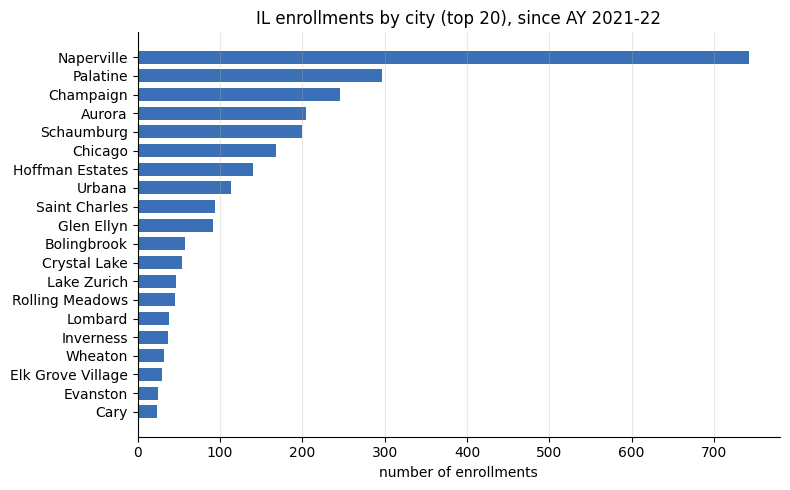

,enrollments,share_%
city_clean,,
Naperville,743,22.5
Palatine,297,9.0
Champaign,246,7.5
Aurora,205,6.2
Schaumburg,200,6.1
Chicago,168,5.1
Hoffman Estates,140,4.2
Urbana,113,3.4
Saint Charles,94,2.8


In [11]:
city_counts = df_il["city_clean"].value_counts()
print("distinct IL cities:", len(city_counts))

top20 = city_counts.head(20).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top20.index, top20.values, color="#3b6fb6", height=0.7)
ax.set_title("IL enrollments by city (top 20), since AY 2021-22")
ax.set_xlabel("number of enrollments")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

top20_table = city_counts.head(20).to_frame("enrollments")
# share of all IL enrollments (denominator = every IL enrollment, not just the top 20)
top20_table["share_%"] = (top20_table["enrollments"] / city_counts.sum() * 100).round(1)
top20_table

### 1.6 Result: `df_enrollment`
One row = one IL enrollment, with clean city and academic year.

In [12]:
df_enrollment = (
    df_il[["_id", "term", "academic_year", "course", "city_clean", "state", "zip",
           "enrollDate", "startDate", "status", "isAdult"]]
    .rename(columns={"_id": "student_id", "city_clean": "city"})
    .reset_index(drop=True)
)
print(df_enrollment.shape)
df_enrollment.head(10)

(3302, 11)


,student_id,term,academic_year,course,city,state,zip,enrollDate,startDate,status,isAdult
0,6126414509152102b965f7a9,120227,2021-22,286,Naperville,IL,60564-8907,2021-08-24 20:07:52,2021-08-24 05:00:00.000,Completed,False
1,6126414609152102b965f7ab,120227,2021-22,220,Champaign,IL,61821-7030,2021-08-24 22:01:21,2021-09-07 05:00:00.000,Completed,True
2,6126414609152102b965f7ad,120227,2021-22,241,Riverwoods,IL,60015-1707,2021-08-24 22:17:01,2021-09-22 13:10:23.615,Withdrawn,False
3,612792c6199f3e006569b48d,120227,2021-22,241,Decatur,IL,62521-8637,2021-08-25 20:10:26,2021-08-25 05:00:00.000,Withdrawn,False
4,612792c6199f3e006569b48f,120227,2021-22,241,Champaign,IL,61822-5248,2021-08-25 20:24:22,2021-08-25 05:00:00.000,Withdrawn,False
5,612792c7199f3e006569b491,120227,2021-22,286,Hinsdale,IL,60521-3233,2021-08-25 20:35:46,2021-08-25 05:00:00.000,Completed,False
6,612792c9199f3e006569b49b,120227,2021-22,416,Huntley,IL,60142-2362,2021-08-25 21:25:21,2021-09-08 05:00:00.000,Completed,True
7,6128e44913b609010c53f4f8,120227,2021-22,285,Saint Charles,IL,60174-1201,2021-08-26 21:40:32,2021-08-26 05:00:00.000,Completed,False
8,612cd8ca8a8c8b0184f7ea2d,120227,2021-22,241,Rolling Meadows,IL,60008-3456,2021-08-27 18:58:48,2021-08-27 05:00:00.000,Completed,False
9,612cd8cb8a8c8b0184f7ea33,120227,2021-22,447,Crystal Lake,IL,60014-4123,2021-08-27 21:18:01,2021-09-10 05:00:00.000,Completed,True


## 2. Enrollment trends
### 2.1 Courses by academic year
Count enrollments per course per academic year. The full table (rows = course, columns = academic year, partial years marked with `*`) is saved to `data/processed/` instead of displayed -- the line chart below is the main view.

In [13]:
course_by_year = (
    df_enrollment.groupby(["academic_year", "course"])
    .size()
    .unstack("academic_year", fill_value=0)
)
course_by_year["total"] = course_by_year.sum(axis=1)
course_by_year = course_by_year.sort_values("total", ascending=False)
course_by_year.columns = [f"{c}*" if c in PARTIAL_YEARS else c for c in course_by_year.columns]

# full table saved to data/processed (gitignored) -- see the chart below for the trend
course_by_year.to_csv("../data/processed/03_course_by_year.csv")
print("saved to data/processed/03_course_by_year.csv")

saved to data/processed/03_course_by_year.csv


MATH 241 is far larger than every other course, so it gets its own panel -- otherwise the other courses flatten to the bottom of a shared axis. Full academic years only.

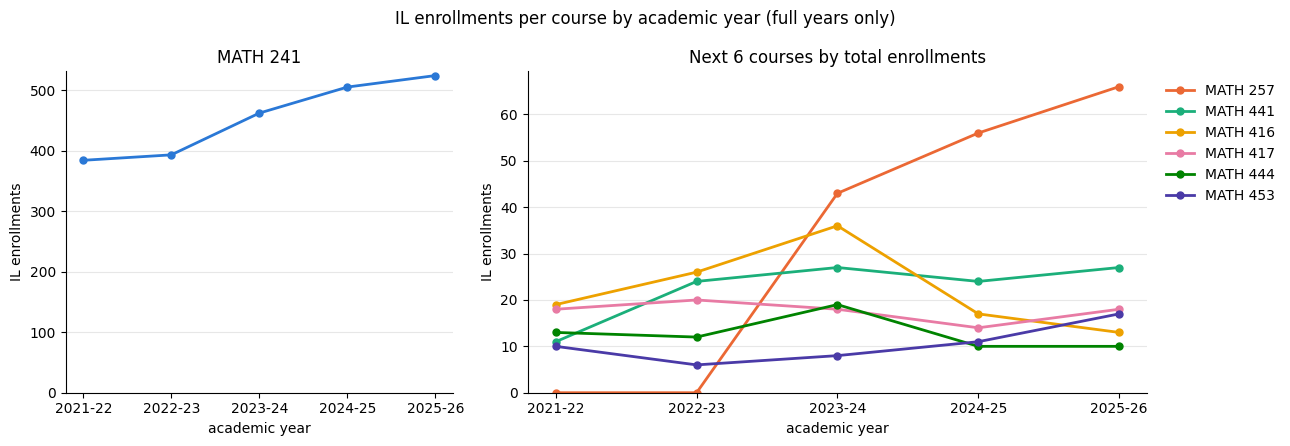

In [14]:
full_years = sorted(y for y in df_enrollment["academic_year"].unique() if y not in PARTIAL_YEARS)
trend = (
    df_enrollment[df_enrollment["academic_year"].isin(full_years)]
    .groupby(["academic_year", "course"]).size()
    .unstack("course", fill_value=0)
)
top_courses = trend.sum().sort_values(ascending=False)
main_course = top_courses.index[0]
other_top = top_courses.index[1:7]

SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 1.6]})

ax1.plot(trend.index, trend[main_course], color=SERIES_COLORS[0], linewidth=2, marker="o", markersize=5)
ax1.set_title(f"MATH {main_course}")
ax1.set_ylim(bottom=0)

for color, course in zip(SERIES_COLORS[1:], other_top):
    ax2.plot(trend.index, trend[course], color=color, linewidth=2, marker="o", markersize=5, label=f"MATH {course}")
ax2.set_title("Next 6 courses by total enrollments")
ax2.set_ylim(bottom=0)
ax2.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

for ax in (ax1, ax2):
    ax.set_xlabel("academic year")
    ax.set_ylabel("IL enrollments")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("IL enrollments per course by academic year (full years only)")
plt.tight_layout()
plt.show()

### 2.2 Courses by city
Rows = city (top 20 by total enrollments), columns = course, values = enrollment count (all years combined).

In [15]:
TOP_N_CITIES = 20

city_by_course = (
    df_enrollment.groupby(["city", "course"])
    .size()
    .unstack("course", fill_value=0)
)
# order course columns by overall popularity
city_by_course = city_by_course[df_enrollment["course"].value_counts().index]
city_by_course["total"] = city_by_course.sum(axis=1)
city_by_course = city_by_course.sort_values("total", ascending=False)

# show every course column (pandas hides the middle ones by default)
with pd.option_context("display.max_columns", None, "display.width", None):
    display(city_by_course.head(TOP_N_CITIES))

course,241,257,441,416,417,444,453,442,285,447,112,415,115,490,220,423,231,461,286,448,446,234,481,314,292,114,100,200,total
city,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Naperville,670,20,12,5,1,1,3,4,11,0,2,4,1,0,1,0,1,1,4,1,0,0,1,0,0,0,0,0,743
Palatine,245,33,0,1,0,1,0,0,11,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,297
Champaign,15,10,37,37,30,15,12,15,2,10,5,6,2,9,6,4,3,4,0,3,4,3,6,1,2,2,2,1,246
Aurora,192,5,1,0,1,2,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,205
Schaumburg,186,7,3,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,200
Chicago,19,13,10,18,8,18,8,8,4,11,8,1,4,8,5,4,5,5,0,2,2,3,1,1,0,1,0,1,168
Hoffman Estates,113,13,2,3,1,1,2,0,2,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,140
Urbana,28,8,13,9,14,9,5,6,2,3,1,2,1,2,0,0,0,1,0,1,3,0,1,3,1,0,0,0,113
Saint Charles,87,1,0,0,1,0,0,0,1,0,2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,94


In [16]:
# same table as row % -- what share of each city's enrollments goes to each course
top_city_share = city_by_course.head(TOP_N_CITIES).drop(columns="total")
top_city_share = (top_city_share.div(top_city_share.sum(axis=1), axis=0) * 100).round(1)
with pd.option_context("display.max_columns", None, "display.width", None):
    display(top_city_share)

course,241,257,441,416,417,444,453,442,285,447,112,415,115,490,220,423,231,461,286,448,446,234,481,314,292,114,100,200
city,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Naperville,90.2,2.7,1.6,0.7,0.1,0.1,0.4,0.5,1.5,0.0,0.3,0.5,0.1,0.0,0.1,0.0,0.1,0.1,0.5,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0
Palatine,82.5,11.1,0.0,0.3,0.0,0.3,0.0,0.0,3.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Champaign,6.1,4.1,15.0,15.0,12.2,6.1,4.9,6.1,0.8,4.1,2.0,2.4,0.8,3.7,2.4,1.6,1.2,1.6,0.0,1.2,1.6,1.2,2.4,0.4,0.8,0.8,0.8,0.4
Aurora,93.7,2.4,0.5,0.0,0.5,1.0,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0
Schaumburg,93.0,3.5,1.5,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Chicago,11.3,7.7,6.0,10.7,4.8,10.7,4.8,4.8,2.4,6.5,4.8,0.6,2.4,4.8,3.0,2.4,3.0,3.0,0.0,1.2,1.2,1.8,0.6,0.6,0.0,0.6,0.0,0.6
Hoffman Estates,80.7,9.3,1.4,2.1,0.7,0.7,1.4,0.0,1.4,0.0,0.0,0.7,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Urbana,24.8,7.1,11.5,8.0,12.4,8.0,4.4,5.3,1.8,2.7,0.9,1.8,0.9,1.8,0.0,0.0,0.0,0.9,0.0,0.9,2.7,0.0,0.9,2.7,0.9,0.0,0.0,0.0
Saint Charles,92.6,1.1,0.0,0.0,1.1,0.0,0.0,0.0,1.1,0.0,2.1,1.1,0.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# save both 2.2 tables to data/processed (gitignored) for download
city_by_course.head(TOP_N_CITIES).to_csv("../data/processed/03_city_by_course_top20.csv")
top_city_share.to_csv("../data/processed/03_city_by_course_share_top20.csv")
print("saved to data/processed/")

saved to data/processed/


## 3. Exclude Students From Partner High Schools
### 3.1 Add `isPartner` to `df_enrollment`
`isPartner` comes from the raw `students` record. `df_il` still has every raw column, so map it onto `df_enrollment` by `_id` (one `students` record = one row, so `_id` is unique).

In [18]:
print("_id unique in df_il:", df_il["_id"].is_unique)
print("isPartner types:", df_il["isPartner"].map(lambda v: type(v).__name__).value_counts().to_dict())
df_il["isPartner"].value_counts(dropna=False)

_id unique in df_il: True
isPartner types: {'bool': 3302}


isPartner
True     2195
False    1107
Name: count, dtype: int64

In [19]:
partner_by_id = df_il.set_index("_id")["isPartner"]
df_enrollment["isPartner"] = df_enrollment["student_id"].map(partner_by_id)

print("rows with no isPartner match:", df_enrollment["isPartner"].isna().sum())
df_enrollment.head()

rows with no isPartner match: 0


,student_id,term,academic_year,course,city,state,zip,enrollDate,startDate,status,isAdult,isPartner
0,6126414509152102b965f7a9,120227,2021-22,286,Naperville,IL,60564-8907,2021-08-24 20:07:52,2021-08-24 05:00:00.000,Completed,False,False
1,6126414609152102b965f7ab,120227,2021-22,220,Champaign,IL,61821-7030,2021-08-24 22:01:21,2021-09-07 05:00:00.000,Completed,True,False
2,6126414609152102b965f7ad,120227,2021-22,241,Riverwoods,IL,60015-1707,2021-08-24 22:17:01,2021-09-22 13:10:23.615,Withdrawn,False,False
3,612792c6199f3e006569b48d,120227,2021-22,241,Decatur,IL,62521-8637,2021-08-25 20:10:26,2021-08-25 05:00:00.000,Withdrawn,False,False
4,612792c6199f3e006569b48f,120227,2021-22,241,Champaign,IL,61822-5248,2021-08-25 20:24:22,2021-08-25 05:00:00.000,Withdrawn,False,False


### 3.2 Drop partner rows
Keep only rows where `isPartner` is not `True`.

In [20]:
df_enrollment_np = df_enrollment[df_enrollment["isPartner"] != True].reset_index(drop=True)

print("before:", len(df_enrollment), "-> after:", len(df_enrollment_np),
      f"(dropped {len(df_enrollment) - len(df_enrollment_np)} partner rows)")
print("missing isPartner kept:", df_enrollment_np["isPartner"].isna().sum())

# how many partner enrollments were removed per academic year
df_enrollment.groupby("academic_year")["isPartner"].agg(
    total="size", partner=lambda s: (s == True).sum()
).assign(non_partner=lambda t: t["total"] - t["partner"])

before: 3302 -> after: 1107 (dropped 2195 partner rows)
missing isPartner kept: 0


,total,partner,non_partner
academic_year,,,
2021-22,641,348,293
2022-23,543,393,150
2023-24,670,435,235
2024-25,686,511,175
2025-26,727,508,219
2026-27,35,0,35


## 4. Enrollment Map

### 4.1 Fill missing locations from `location.formatted`
3438 rows in the window have no `address` at all (state and country both empty), so they can't be put in any group. Every `students` record has a geocoded `location.formatted` string (e.g. `314 E White St #304, Champaign, IL 61820, USA`) -- parse it to fill the gaps (`fill_location_from_formatted` in `src/location.py`):
- Only **missing** `city` / `state` / `zip` / `country` are filled; values from `address` are never overwritten.
- US strings give state (2-letter code or full name), zip and city. Non-US strings only give `country` -- their formats vary too much to pick out a city reliably.
- `NOTFOUND` (geocoder failure) is treated as missing.
- Geocoder country names are mapped to the spelling already used in `address.country` (e.g. `China` -> `China, Peoples Republic of`).

Check first what the strings look like for the rows with no address.

In [21]:
no_addr = df_raw["state"].isna() & df_raw["country"].isna()
print("rows with no state and no country:", no_addr.sum())
print("  ...of which have a formatted_location:",
      (no_addr & df_raw["formatted_location"].fillna("").str.strip().ne("")).sum())
df_raw.loc[no_addr, "formatted_location"].sample(15, random_state=0)

rows with no state and no country: 3438
  ...of which have a formatted_location: 8


2702    None
4712    None
7318    None
9458    None
4192    None
4209    None
6552    None
6613    None
4974    None
4490    None
7371    None
6735    None
2991    None
6871    None
4650    None
Name: formatted_location, dtype: object

In [22]:
from src.location import fill_location_from_formatted

df_loc = fill_location_from_formatted(df_raw)
print("rows filled:", df_loc["location_filled"].sum())
print("still no state and no country:", (df_loc["state"].isna() & df_loc["country"].isna()).sum(), "\n")

# what got filled, by resulting country
print(df_loc.loc[df_loc["location_filled"], "country"].value_counts(dropna=False).head(15), "\n")

# geocoder country names not seen in address.country -- may need an alias in FORMATTED_COUNTRY_ALIASES
known = set(df_raw["country"].dropna())
new_names = df_loc.loc[df_loc["location_filled"] & ~df_loc["country"].isin(known), "country"]
print("filled country names not in address.country:", new_names.value_counts().to_dict())

# filled US rows whose state couldn't be read
df_loc.loc[df_loc["location_filled"] & (df_loc["country"] == "United States") & df_loc["state"].isna(),
           "formatted_location"].head(10)

rows filled: 20
still no state and no country: 3436 

country
China, Peoples Republic of    15
United States                  2
Hong Kong                      1
Korea, South                   1
Canada                         1
Name: count, dtype: int64 

filled country names not in address.country: {'Hong Kong': 1}


Series([], Name: formatted_location, dtype: object)

Only a handful of the no-address rows have a `formatted_location` at all, so this recovers very little. What are the rows that are still missing?
- Are they mostly partner rows? Those get dropped in 4.3 anyway.
- Does the same person (`netId`) have an address on another enrollment we could borrow?

In [23]:
still_missing = df_loc["state"].isna() & df_loc["country"].isna()
print("still missing:", still_missing.sum())
print("  isPartner:", df_loc.loc[still_missing, "isPartner"].value_counts(dropna=False).to_dict())
print("  by academic year:", df_loc.loc[still_missing, "term"].map(term_to_academic_year).value_counts().sort_index().to_dict())
print("  has an address dict at all:", df_loc.loc[still_missing, "address"].map(lambda a: isinstance(a, dict) and len(a) > 0).sum())

# same netId with a usable location on another enrollment in the window
has_loc_netids = set(df_loc.loc[~(df_loc["state"].isna() & df_loc["country"].isna()), "netId"])
missing_np = still_missing & (df_loc["isPartner"] != True)
print("\nnon-partner still missing:", missing_np.sum())
print("  ...whose netId has a location on another enrollment:", df_loc.loc[missing_np, "netId"].isin(has_loc_netids).sum())

still missing: 3436
  isPartner: {False: 3431, True: 5}
  by academic year: {'2021-22': 4, '2022-23': 936, '2023-24': 913, '2024-25': 907, '2025-26': 676}
  has an address dict at all: 6

non-partner still missing: 3431
  ...whose netId has a location on another enrollment: 303


In [24]:
# which raw fields are filled for missing rows vs rows with a location -- where else could location live?
coverage = pd.DataFrame({
    "missing_rows_%": df_loc[still_missing].notna().mean() * 100,
    "located_rows_%": df_loc[~still_missing].notna().mean() * 100,
}).round(1)
with pd.option_context("display.max_rows", None):
    display(coverage.sort_values("missing_rows_%"))

with pd.option_context("display.max_columns", None, "display.width", None):
    display(df_loc[still_missing].head(10))

,missing_rows_%,located_rows_%
inactiveEmail,0.0,0.8
proctorUAccessCode,0.0,0.0
zip,0.0,99.5
state,0.0,85.1
city,0.0,100.0
street,0.0,100.0
prairieLearn,0.0,5.3
country,0.0,100.0
courseOrientation,0.0,4.9
moodle,0.0,38.5


,_id,name,mathable,mentor,location,netId,email,otherEmails,defunctEmails,phones,status,tags,subject,format,roster,grades,proctor,flagged,proctorUAccessCode,version,uin,address,course,section,isAdult,isContract,isPartner,crn,term,creditHours,enrollDate,startDate,endDate,extensions,created,notifications,gradingScale,isCurrent,__v,boxFolder,activationCode,welcomeEmail,courseOrientation,preCheck,finalExam,hasCompletedQualtricsSurvey,completeDate,finalGrade,withdrawDate,moodle,inactiveEmail,personal,accommodation,prairieLearn,street,city,state,zip,formatted_location,country,location_filled
1370,62e7ce507f33db00072879b0,"{'first': 'Michael', 'last': 'Rok'}",{'loginToken': ''},{'comments': []},NaN,mrok2,mrok2@illinois.edu,[],[],[],Withdrawn,[],MATH,Mathable,[],[],[],0,None,0,673449677,NaN,461,XGR,True,False,False,41584.0,120228,NaN,2022-08-01 13:00:00.837,NaT,NaT,[],2022-08-01 13:00:00.841,[],58500f7cc061892a5cd0d9bf,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,2022-08-16 13:00:01.061,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,NaN,False
1371,62e7ce507f33db00072879b1,"{'first': 'Stephen', 'last': 'Palopoli'}",{'loginToken': ''},{'comments': []},NaN,sjp8,sjp8@illinois.edu,[],[],[],Withdrawn,[],MATH,Mathable,[],"[62fbb048d3cc0d00072706bf, 62fbb048d3cc0d00072...",[],0,None,0,669764297,NaN,461,XGR,True,False,False,41584.0,120228,NaN,2022-08-01 13:00:00.837,NaT,NaT,[],2022-08-01 13:00:00.844,[],58500f7cc061892a5cd0d9bf,False,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,2022-08-22 13:00:00.888,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,NaN,False
1389,62f108d1ef97830006002dd5,"{'first': 'Alex', 'last': 'Counseller'}",{'loginToken': ''},"{'comments': [], 'lastResponseDate': 2022-12-0...",NaN,alexc7,alexc7@illinois.edu,[],[],[],Completed,[],MATH,Moodle,"[2022-09-01 05:00:00, 2022-10-01 05:00:00, 202...","[633f3d294b1440000671bb06, 633f3d294b144000067...",[],0,None,0,671321488,NaN,481,XGR,True,False,False,72294.0,120228,NaN,2022-08-08 13:00:01.359,NaT,NaT,[],2022-08-08 13:00:01.370,"[{'type': 'EndOfCourseSurvey', 'date': 2022-12...",5b1d3aadd220b3270e32eb75,False,2,"{'internalId': '176162172873', 'sharedId': '17...",NaN,NaN,NaN,NaN,633f3d294b1440000671bb08,NaN,2022-12-15 19:39:34.188,639b77f60263360006f39801,NaT,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,NaN,False
1424,63037dd0f806940006581380,"{'first': 'Stephen', 'last': 'Palopoli'}",{'loginToken': ''},"{'comments': [], 'lastEmailDate': 2022-10-31 1...",NaN,sjp8,sjp8@illinois.edu,[],[],[],Completed,[],MATH,Moodle,"[2022-09-01 05:00:00, 2022-10-01 05:00:00, 202...","[633f3d454b1440000671bb32, 633f3d454b144000067...",[],0,None,0,669764297,NaN,481,XGR,True,False,False,72294.0,120228,NaN,2022-08-22 13:00:00.828,NaT,NaT,[],2022-08-22 13:00:00.840,"[{'type': 'EndOfCourseSurvey', 'date': 2022-12...",5b1d3aadd220b3270e32eb75,False,2,"{'internalId': '176163192147', 'sharedId': '17...",NaN,NaN,NaN,NaN,633f3d454b1440000671bb34,NaN,2022-12-15 19:46:38.488,639b799e0263360006f3985d,NaT,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,NaN,False
1610,6331a4c55bf9080006f60efc,"{'first': 'Shreya', 'last': 'Sridhar'}","{'userId': 'netmathphs_sridhar2915', 'courseId...",{'comments': []},{'formatted': 'NOTFOUND'},shreya30,shreya30@illinois.edu,[shreyasridhar10@gmail.com],[],[],Completed,[],MATH,Mathable,[],"[645e672243f8de00066fc527, 6425d11f1dc01400071...",[59e38d3424bccd2572746627],0,None,0,665923041,"{'street': '', 'city': '', 'state': '', 'zip':...",241,CTB,False,True,True,10255.0,120237,4.0,2022-09-23 19:33:10.000,2022-09-23 05:00:00,2023-06-22 05:00:00,"[{'_id': 63529a3c3ac9c50007eff4d4, 'type': 'or...",2022-09-26 13:10:29.254,[],58500f7cc061892a5cd0d9c1,False,19,NaN,NaN,NaN,NaN,NaN,64678572cae456000652d38a,NaN,2023-05-19 18:06:53.659,6467babdcae456000652fc96,NaT,NaN,NaN,NaN,{'examTimeMultiplier': 1},NaN,None,None,None,None,NOTFOUND,NaN,False
1631,6332f63f5bf9080006fbfd1e,"{'first': 'Noam', 'last': 'Kramer'}","{'userId': 'netmathphs_noamkramer', 'courseId'...",{'comments': []},{'formatted': 'NOTFOUND'},nkramer,nk

### 4.2 Split into in-state / out-of-state / international
Same window as the rest of the notebook (`df_loc` = `df_raw` after 4.1, `term >= START_TERM`, so it also includes the partial AY 2026-27, like `cleaned_in_state`). Every row goes into exactly one group:
- **in_state**: `state == "IL"` (same rule as `df_il` in 1.2)
- **out_of_state**: `state` is a US code other than `IL`
- **international**: `state` is not a US code and `country` is set to something other than `United States`
- **unclassified**: everything else (e.g. no usable `formatted_location`, or a US address whose state couldn't be read). These rows are left out of all three tables.

Check first: rows that might be in the wrong group.

In [25]:
from src.location import US_STATE_CODES

is_us_state = df_loc["state"].isin(US_STATE_CODES)
has_foreign_country = df_loc["country"].notna() & (df_loc["country"] != "United States")

loc_group = pd.Series("unclassified", index=df_loc.index)
loc_group[df_loc["state"] == "IL"] = "in_state"
loc_group[is_us_state & (df_loc["state"] != "IL")] = "out_of_state"
loc_group[~is_us_state & has_foreign_country] = "international"
print(loc_group.value_counts(), "\n")

# US state code but a non-US country -- grouped by state above, check these look right
print("US state + non-US country:", (is_us_state & has_foreign_country).sum())
# other spellings of the US that would wrongly land in international
us_like = df_loc["country"].astype(str).str.match(r"^\s*(u\.?s\.?a?\.?|united states.*|america)\s*$", case=False)
print("US-like country values other than 'United States':",
      df_loc.loc[us_like & (df_loc["country"] != "United States"), "country"].value_counts().to_dict())

# what is unclassified?
df_loc.loc[loc_group == "unclassified", ["state", "country"]].value_counts(dropna=False)

unclassified     3436
in_state         3315
out_of_state     2350
international    1083
Name: count, dtype: int64 

US state + non-US country: 15
US-like country values other than 'United States': {}


state  country
NaN    NaN        3436
Name: count, dtype: int64

### 4.3 Build `cleaned_in_state`, `cleaned_out_of_state`, `cleaned_international`
All three are built the same way as `df_enrollment_np` (3.2): academic year from `term`, cleaned city spelling (the 1.5 rule, applied within each group), partner rows dropped, same columns in the same order.

`cleaned_in_state` is rebuilt here rather than copied from `df_enrollment_np`, so it also picks up the IL rows recovered in 4.1. Sections 1-3 still use the unfilled `df_il`.

For non-Latin city names, `city_key` would strip every character and leave an empty key, so those keep their raw spelling instead of all being merged into one.

In [26]:
def build_cleaned(df):
    df = df.copy()
    df["academic_year"] = df["term"].map(term_to_academic_year)

    key = df["city"].map(city_key, na_action="ignore")
    key = key.where(key != "", df["city"])  # empty key -> keep raw city
    canonical = df.assign(city_key=key).groupby("city_key")["city"].agg(lambda s: s.value_counts().index[0])
    df["city"] = key.map(canonical)

    df = df.rename(columns={"_id": "student_id"})
    df = df[df["isPartner"] != True]
    return df[list(df_enrollment_np.columns)].reset_index(drop=True)

cleaned_in_state = build_cleaned(df_loc[loc_group == "in_state"])
cleaned_out_of_state = build_cleaned(df_loc[loc_group == "out_of_state"])
cleaned_international = build_cleaned(df_loc[loc_group == "international"])

# sanity check: every df_enrollment_np row (3.2) is still in cleaned_in_state; the rest are recovered by 4.1
assert set(df_enrollment_np["student_id"]) <= set(cleaned_in_state["student_id"])
print("cleaned_in_state:", len(df_enrollment_np), "rows from 3.2 +",
      len(cleaned_in_state) - len(df_enrollment_np), "recovered from formatted_location\n")

for name, d, grp in [("cleaned_in_state", cleaned_in_state, "in_state"),
                     ("cleaned_out_of_state", cleaned_out_of_state, "out_of_state"),
                     ("cleaned_international", cleaned_international, "international")]:
    print(f"{name:<22} {d.shape}  partner rows dropped: {(loc_group == grp).sum() - len(d)}")

cleaned_in_state: 1107 rows from 3.2 + 12 recovered from formatted_location

cleaned_in_state       (1119, 12)  partner rows dropped: 2196
cleaned_out_of_state   (2304, 12)  partner rows dropped: 46
cleaned_international  (1083, 12)  partner rows dropped: 0


### 4.4 Overlap check
The three tables can't share a row (`student_id` = one enrollment record). The same *person* (`netId`) can still show up in two tables if their address changed between enrollments -- count how often that happens.

In [27]:
ids = [set(d["student_id"]) for d in (cleaned_in_state, cleaned_out_of_state, cleaned_international)]
print("shared enrollment ids:", len(ids[0] & ids[1]) + len(ids[0] & ids[2]) + len(ids[1] & ids[2]))

net_group = pd.concat([
    df_raw.set_index("_id").loc[d["student_id"], ["netId"]].assign(group=name)
    for name, d in [("in_state", cleaned_in_state), ("out_of_state", cleaned_out_of_state),
                    ("international", cleaned_international)]
])
multi = net_group.groupby("netId")["group"].nunique()
print("netIds in more than one table:", (multi > 1).sum(), "of", len(multi))
net_group[net_group["netId"].isin(multi[multi > 1].index)].groupby("netId")["group"].agg(lambda g: " + ".join(sorted(set(g)))).value_counts()

shared enrollment ids: 0
netIds in more than one table: 30 of 3468


group
in_state + international                   23
international + out_of_state                4
in_state + out_of_state                     2
in_state + international + out_of_state     1
Name: count, dtype: int64

### 4.5 Preview the three tables

In [28]:
for name, d in [("cleaned_in_state", cleaned_in_state),
                ("cleaned_out_of_state", cleaned_out_of_state),
                ("cleaned_international", cleaned_international)]:
    print(name, d.shape)
    with pd.option_context("display.max_columns", None, "display.width", None):
        display(d.head())

cleaned_in_state (1119, 12)


,student_id,term,academic_year,course,city,state,zip,enrollDate,startDate,status,isAdult,isPartner
0,6126414509152102b965f7a9,120227,2021-22,286,Naperville,IL,60564-8907,2021-08-24 20:07:52,2021-08-24 05:00:00.000,Completed,False,False
1,6126414609152102b965f7ab,120227,2021-22,220,Champaign,IL,61821-7030,2021-08-24 22:01:21,2021-09-07 05:00:00.000,Completed,True,False
2,6126414609152102b965f7ad,120227,2021-22,241,Riverwoods,IL,60015-1707,2021-08-24 22:17:01,2021-09-22 13:10:23.615,Withdrawn,False,False
3,612792c6199f3e006569b48d,120227,2021-22,241,Decatur,IL,62521-8637,2021-08-25 20:10:26,2021-08-25 05:00:00.000,Withdrawn,False,False
4,612792c6199f3e006569b48f,120227,2021-22,241,Champaign,IL,61822-5248,2021-08-25 20:24:22,2021-08-25 05:00:00.000,Withdrawn,False,False


cleaned_out_of_state (2304, 12)


,student_id,term,academic_year,course,city,state,zip,enrollDate,startDate,status,isAdult,isPartner
0,612792c6199f3e006569b48b,120227,2021-22,241,Union City,CA,94587-5596,2021-08-25 19:21:24,2021-08-25 05:00:00.000,Completed,False,False
1,612792c7199f3e006569b493,120227,2021-22,285,Wildwood,MO,63005-4259,2021-08-25 20:43:47,2021-10-06 13:10:24.740,Withdrawn,True,False
2,612792c8199f3e006569b495,120227,2021-22,461,Seattle,WA,98105-4006,2021-08-25 20:57:38,2021-09-08 05:00:00.000,Withdrawn,True,False
3,612792c8199f3e006569b497,120227,2021-22,220,Oviedo,FL,32765-4009,2021-08-25 21:03:11,2021-09-08 05:00:00.000,Completed,True,False
4,612cd8cb8a8c8b0184f7ea2f,120227,2021-22,241,Princeton,NJ,08540-2700,2021-08-27 20:44:21,2021-08-27 05:00:00.000,Completed,False,False


cleaned_international (1083, 12)


,student_id,term,academic_year,course,city,state,zip,enrollDate,startDate,status,isAdult,isPartner
0,612792c8199f3e006569b499,120227,2021-22,415,Kolkata West Bengal,None,700075,2021-08-25 21:12:10,2021-09-08 05:00:00,Withdrawn,True,False
1,612792ca199f3e006569b49d,120227,2021-22,415,Seoul,None,07222,2021-08-25 21:45:02,2021-09-08 05:00:00,Completed,True,False
2,6130cd48696c46005d066d99,120227,2021-22,442,Seoul,None,08742,2021-09-01 20:30:41,2021-09-15 05:00:00,Completed,True,False
3,61321ec8c4068d0105c96e8e,120227,2021-22,444,Wuhan,None,430072,2021-09-02 14:28:48,2021-09-16 05:00:00,Completed,True,False
4,6136134d22500c006ced81b3,120227,2021-22,447,Baku Absheron,None,AZ1073,2021-09-03 21:12:33,2021-09-17 05:00:00,Withdrawn,True,False


## 5. Regional enrollment map
Color = number of enrollments (non-partner, whole window incl. the partial AY 2026-27). Rows without any location (4.1) can't be placed and are not on the maps.

One combined table with a `region` column, plus `country` looked up from `df_loc` (the cleaned tables don't carry it).

In [29]:
import plotly.express as px
import plotly.io as pio

# PyCharm doesn't display plotly's interactive output -> show maps as static images (kaleido)
pio.renderers.default = "png"
pio.renderers["png"].width = 1000
pio.renderers["png"].height = 600

country_by_id = df_loc.set_index("_id")["country"]
df_region = pd.concat([
    cleaned_in_state.assign(region="Illinois"),
    cleaned_out_of_state.assign(region="Out-of-state"),
    cleaned_international.assign(region="International"),
], ignore_index=True)
df_region["country"] = df_region["student_id"].map(country_by_id)
df_region["region"].value_counts()

region
Out-of-state     2304
Illinois         1119
International    1083
Name: count, dtype: int64

### 5.1 NetMath enrollments by US state
All 50 states + DC are listed, so states with no enrollments show up as 0 (lightest color) instead of being left blank.

US enrollments outside the 50 states + DC (territories / military): {'AP': 3, 'PR': 1, 'AE': 1}


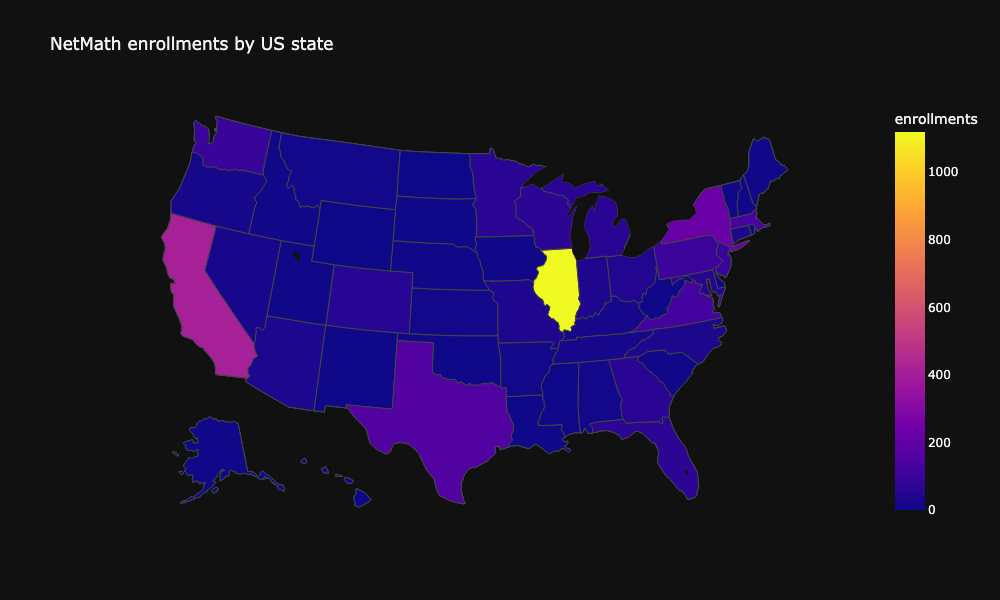

In [30]:
US_MAP_STATES = sorted(US_STATE_CODES - {"PR", "GU", "VI", "AS", "MP", "AA", "AE", "AP"})  # 50 states + DC

us_rows = df_region[df_region["region"] != "International"]
print("US enrollments outside the 50 states + DC (territories / military):",
      us_rows.loc[~us_rows["state"].isin(US_MAP_STATES), "state"].value_counts().to_dict())

state_counts = (
    us_rows["state"].value_counts()
    .reindex(US_MAP_STATES, fill_value=0)
    .rename_axis("state").reset_index(name="enrollments")
)

fig = px.choropleth(state_counts, locations="state", locationmode="USA-states",
                    color="enrollments", scope="usa",
                    title="NetMath enrollments by US state")
fig.show()

In [31]:
print("top 10 states:")
display(state_counts.sort_values("enrollments", ascending=False).head(10).reset_index(drop=True))

print("no enrollments:", state_counts.loc[state_counts["enrollments"] == 0, "state"].tolist())
print("1-5 enrollments:", state_counts.loc[state_counts["enrollments"].between(1, 5), "state"].tolist())

top 10 states:


,state,enrollments
0,IL,1119
1,CA,410
2,NY,225
3,TX,156
4,MA,127
5,VA,119
6,PA,103
7,WA,95
8,NJ,93
9,DC,81


no enrollments: ['ND', 'WY']
1-5 enrollments: ['HI', 'LA', 'MS', 'NM', 'OK', 'SD', 'WV']


### 5.2 NetMath enrollments by city within IL
There are no city outlines to color, so each city is a dot at its location, colored by enrollment count.

Coordinates come from `location.geocode` (the geocoder result stored next to `formatted`). Check its structure first (keys only).

In [32]:
il_location = df_loc.set_index("_id").loc[cleaned_in_state["student_id"], "location"]

def key_tree(x, depth=0, max_depth=4):
    """Structure of a nested dict/list with keys only (no values)."""
    if depth >= max_depth:
        return "..."
    if isinstance(x, dict):
        return {k: key_tree(v, depth + 1) for k, v in x.items()}
    if isinstance(x, list):
        return [key_tree(x[0], depth + 1)] if x else []
    return type(x).__name__

sample = il_location.dropna().iloc[0]
key_tree(sample.get("geocode"))

{'type': 'str', 'coordinates': ['float']}

IL rows with coordinates: 1118 of 1119


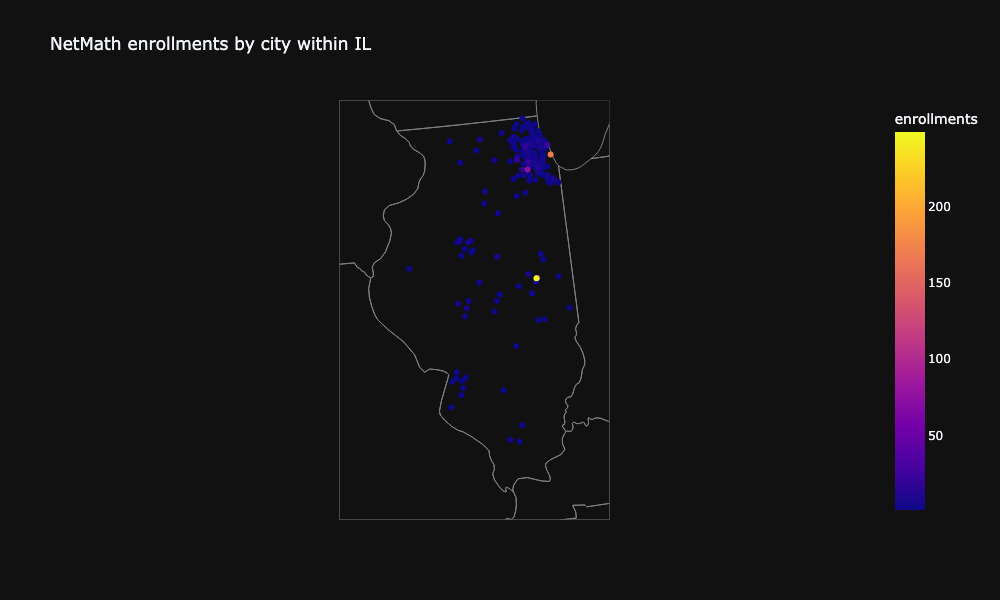

In [33]:
def find_lat_lon(x, path=()):
    """All (path, lat, lon) found anywhere in a nested geocode object."""
    found = []
    if isinstance(x, dict):
        lat = x.get("lat", x.get("latitude"))
        lon = x.get("lng", x.get("lon", x.get("longitude")))
        if isinstance(lat, (int, float)) and isinstance(lon, (int, float)):
            found.append((path, lat, lon))
        coords = x.get("coordinates")
        if isinstance(coords, list) and len(coords) == 2 and all(isinstance(v, (int, float)) for v in coords):
            found.append((path, coords[1], coords[0]))  # GeoJSON is [lon, lat]
        for k, v in x.items():
            found += find_lat_lon(v, path + (k,))
    elif isinstance(x, list):
        for v in x[:1]:  # first geocoder result only
            found += find_lat_lon(v, path)
    return found

def location_lat_lon(loc):
    if not isinstance(loc, dict):
        return (None, None)
    found = find_lat_lon(loc.get("geocode"))
    # prefer the point location over bounds / viewport corners
    point = [f for f in found if f[0] and f[0][-1] == "location"] or found
    return (point[0][1], point[0][2]) if point else (None, None)

il_points = cleaned_in_state[["student_id", "city"]].copy()
il_points[["lat", "lon"]] = il_location.map(location_lat_lon).tolist()
print("IL rows with coordinates:", il_points["lat"].notna().sum(), "of", len(il_points))

# one dot per city: median coordinate of its students (robust to a few bad geocodes)
city_points = (
    il_points.dropna(subset=["lat", "lon"])
    .groupby("city")
    .agg(enrollments=("student_id", "size"), lat=("lat", "median"), lon=("lon", "median"))
    .reset_index()
    .sort_values("enrollments")  # darkest (biggest) cities drawn last, on top
)

fig = px.scatter_geo(city_points, lat="lat", lon="lon", color="enrollments",
                     hover_name="city", scope="north america",
                     title="NetMath enrollments by city within IL")
fig.update_geos(resolution=50, showsubunits=True, subunitcolor="gray",
                lataxis_range=[36.8, 42.7], lonaxis_range=[-91.7, -87.3])  # Illinois
fig.show()

### 5.3 NetMath enrollments by country (world map)
Plotly needs ISO-3 country codes. Codes come from plotly's bundled `gapminder` table, plus manual codes for the spellings used in `address.country`. Any country still without a code is printed and left off the map.

The US is left out: with ~3,400 enrollments it would be the only dark country and every other country would look the same.

countries with no ISO-3 code (not on the map): []


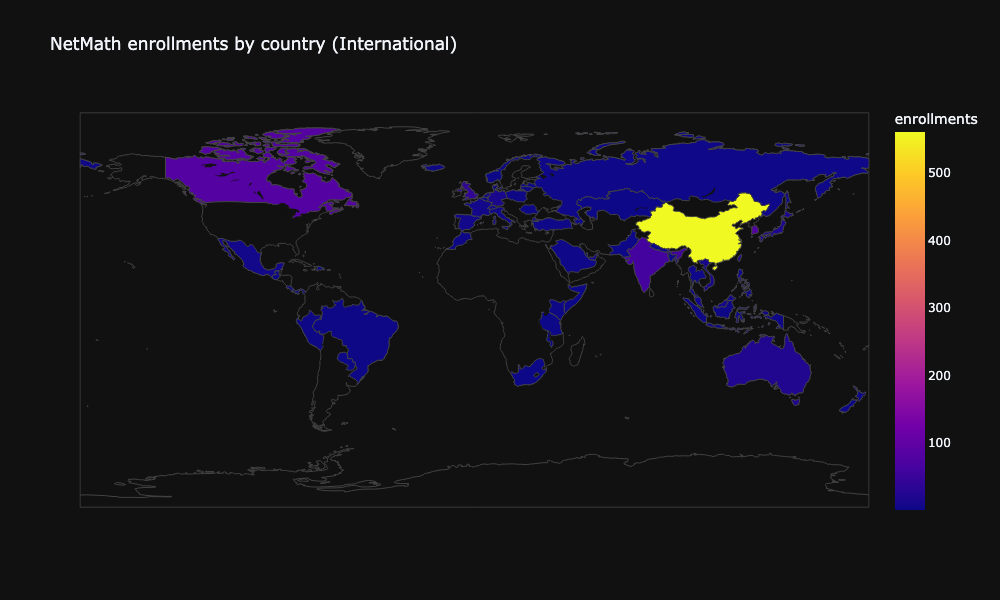

In [34]:
gap = px.data.gapminder()[["country", "iso_alpha"]].drop_duplicates()
COUNTRY_ISO3 = dict(zip(gap["country"], gap["iso_alpha"]))
COUNTRY_ISO3.update({
    "China, Peoples Republic of": "CHN", "Korea, South": "KOR", "Hong Kong": "HKG",
    "Hong Kong (China)": "HKG", "Taiwan": "TWN", "Russia": "RUS", "Vietnam": "VNM",
    "United Arab Emirates": "ARE", "Azerbaijan": "AZE", "Qatar": "QAT", "Lithuania": "LTU",
    "Kazakhstan": "KAZ", "Latvia": "LVA", "Grenada": "GRD",
})

country_counts = (
    df_region.loc[df_region["region"] == "International", "country"]
    .value_counts().rename_axis("country").reset_index(name="enrollments")
)
country_counts["iso3"] = country_counts["country"].map(COUNTRY_ISO3)
print("countries with no ISO-3 code (not on the map):",
      country_counts.loc[country_counts["iso3"].isna(), "country"].tolist())

fig = px.choropleth(country_counts.dropna(subset=["iso3"]), locations="iso3",
                    color="enrollments", hover_name="country",
                    title="NetMath enrollments by country (International)")
fig.show()

In [35]:
country_counts.head(15)

,country,enrollments,iso3
0,"China, Peoples Republic of",561,CHN
1,Canada,85,CAN
2,"Korea, South",81,KOR
3,India,61,IND
4,Singapore,46,SGP
5,United Kingdom,40,GBR
6,Australia,23,AUS
7,Japan,19,JPN
8,Taiwan,18,TWN
9,Germany,14,DEU


## 6. Enrollment trends: Illinois vs out-of-state vs international
Full academic years only.

**Caveat first:** the rows with no location (4.1) are not spread evenly over time -- almost none in AY 2021-22, ~900 per year after. Every region's raw count is therefore undercounted from 2022-23 on, and a drop between 2021-22 and 2022-23 may be partly this, not real. The **shares** in 6.2 are safer to compare across years, as long as the missing rows aren't concentrated in one region.

In [36]:
full_years = sorted(y for y in df_region["academic_year"].unique() if y not in PARTIAL_YEARS)

# non-partner rows in the window: located vs no location, per year
np_rows = df_loc[df_loc["isPartner"] != True]
coverage_by_year = pd.crosstab(
    np_rows["term"].map(term_to_academic_year),
    np.where(loc_group[np_rows.index] == "unclassified", "no location", "located"),
)
coverage_by_year["no_location_%"] = (coverage_by_year["no location"] / coverage_by_year.sum(axis=1) * 100).round(1)
coverage_by_year

col_0,located,no location,no_location_%
term,,,
2021-22,1036,4,0.4
2022-23,573,933,62.0
2023-24,859,912,51.5
2024-25,745,906,54.9
2025-26,1089,676,38.3
2026-27,204,0,0.0


### 6.1 Enrollments per year by region

region,Illinois,Out-of-state,International
academic_year,,,
2021-22,295,512,229
2022-23,152,295,126
2023-24,237,396,226
2024-25,177,378,190
2025-26,223,597,269


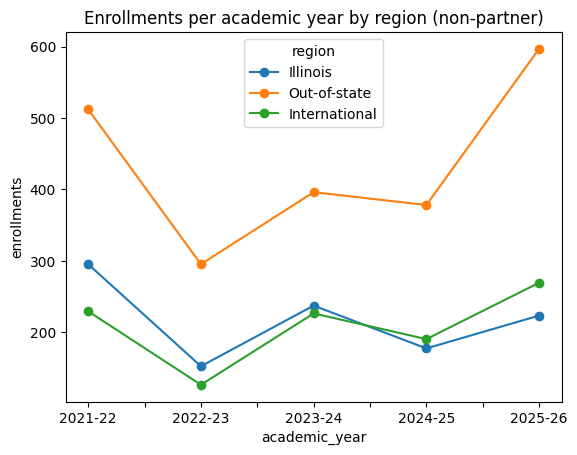

In [37]:
region_trend = (
    df_region[df_region["academic_year"].isin(full_years)]
    .groupby(["academic_year", "region"]).size()
    .unstack("region", fill_value=0)
    [["Illinois", "Out-of-state", "International"]]
)
display(region_trend)

region_trend.plot(marker="o", title="Enrollments per academic year by region (non-partner)", ylabel="enrollments")
plt.show()

### 6.2 Share of each year's enrollments by region
Is the mix shifting (e.g. out-of-state / international growing faster than Illinois)?

region,Illinois,Out-of-state,International
academic_year,,,
2021-22,28.5,49.4,22.1
2022-23,26.5,51.5,22.0
2023-24,27.6,46.1,26.3
2024-25,23.8,50.7,25.5
2025-26,20.5,54.8,24.7


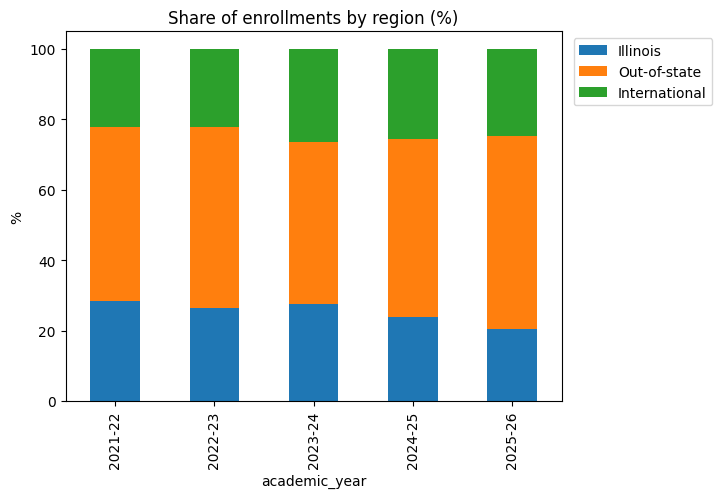

In [38]:
region_share = (region_trend.div(region_trend.sum(axis=1), axis=0) * 100).round(1)
display(region_share)

region_share.plot(kind="bar", stacked=True, title="Share of enrollments by region (%)", ylabel="%")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

### 6.3 Course mix by region
Which courses each region takes, as % of that region's enrollments (all full years combined). Top 10 courses overall.

In [39]:
in_full = df_region[df_region["academic_year"].isin(full_years)]
top_courses_all = in_full["course"].value_counts().head(10).index

course_mix = pd.crosstab(in_full["course"], in_full["region"], normalize="columns").mul(100).round(1)
course_mix.loc[top_courses_all, ["Illinois", "Out-of-state", "International"]]

region,Illinois,Out-of-state,International
course,,,
241,14.3,11.7,9.5
416,10.4,11.4,13.7
444,5.9,13.1,12.6
441,10.5,7.2,9.1
447,3.4,9.4,10.8
417,8.3,8.3,7.4
257,9.5,6.2,7.5
442,4.6,5.6,6.1
453,4.8,2.8,2.1


### 6.4 Course trends by region
For the 6 largest courses: enrollments per year (y-axis = number of enrollment rows), one line per region. Same trend or different trend?

These numbers are much smaller than in section 2 because partner rows are excluded and the count is split three ways. A 4th line, **No location**, shows the non-partner rows that couldn't be placed in any region (4.1), so a dip in the three region lines can be told apart from missing location data.

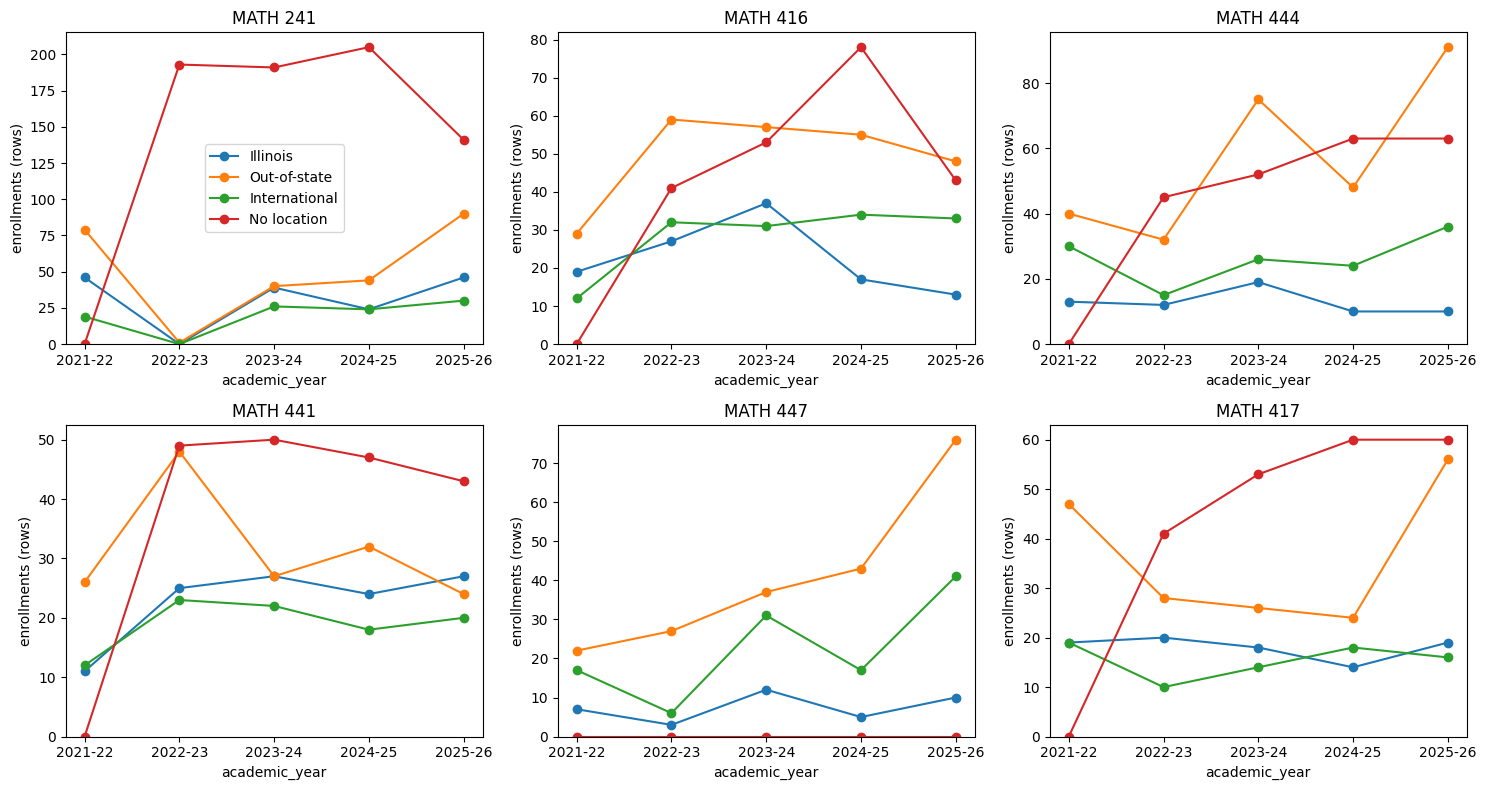

In [40]:
no_location = df_loc[(loc_group == "unclassified") & (df_loc["isPartner"] != True)].assign(
    academic_year=lambda d: d["term"].map(term_to_academic_year), region="No location")
trend_rows = pd.concat([in_full, no_location[no_location["academic_year"].isin(full_years)]], ignore_index=True)
REGION_ORDER = ["Illinois", "Out-of-state", "International", "No location"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, course in zip(axes.flat, top_courses_all[:6]):
    (trend_rows[trend_rows["course"] == course]
     .groupby(["academic_year", "region"]).size()
     .unstack("region", fill_value=0)
     .reindex(index=full_years, columns=REGION_ORDER, fill_value=0)
     .plot(ax=ax, marker="o", title=f"MATH {course}", legend=False, ylabel="enrollments (rows)"))
    ax.set_ylim(bottom=0)
axes.flat[0].legend()
plt.tight_layout()
plt.show()

**Check: MATH 241 in 2022-23.** Section 2 shows ~393 IL enrollments in MATH 241 that year, but 6.4 shows 0 for every region. Where did those rows go? Every MATH 241 row in the window, per year, by partner / location group:

In [41]:
m241 = df_loc[df_loc["course"] == 241]
pd.crosstab(
    m241["term"].map(term_to_academic_year),
    np.where(m241["isPartner"] == True, "partner (excluded)", loc_group[m241.index]),
    margins=True,
)

col_0,in_state,international,out_of_state,partner (excluded),unclassified,All
term,,,,,,
2021-22,46,19,79,384,0,528
2022-23,0,0,1,396,193,590
2023-24,39,26,40,424,191,720
2024-25,24,24,44,482,205,779
2025-26,46,30,90,479,141,786
2026-27,14,11,44,0,0,69
All,169,110,298,2165,730,3472
